In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

pandas version:2.2.2
sqlite3 version:2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/student_performance.csv')


In [ ]:

print(f"dataset size : {len(df)}")

dataset size : 30


In [ ]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
conn=sqlite3.connect('college.db')
#conn=our connection to the database
#college.db=the file will be created in colab's filesystem
#if college.db aldready exits it will create new file with same name
cursor=conn.cursor()

In [ ]:
cursor = conn.cursor()
df.to_sql('students',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("Number of rows inserted into 'students' table",count)

Number of rows inserted into 'students' table 30


In [ ]:
cursor.execute("pragma table_info(students)")
columns_info=cursor.fetchall()
#fetchall retrieve all results rows(not just one)
print("table structure of students: ")
print(f"{'column name':<25}{'data type':<12}")
print("-"*45)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")

table structure of students: 
column name              data type   
---------------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [ ]:
def run_query(sql, description=""):
    """Runs a SQL query and returns results as a pandas dataframe

    Parameters:
    -----------
    sql : str
        SQL query string
    description : str
        Label to print above the results

    Returns:
    --------
    Pandas DataFrame containing the query results
    """

    if description:
        print(f"\n{'='*55}")
        print(description)
        print(f"{'='*55}")

    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))

    return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description)


In [ ]:
run_query(
      "SELECT * FROM students",
          "All Students"
          )


All Students
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78              Delhi            2023
       1004    Sneha Reddy   20 Female       Mechanical         2          70             80             75                 48                     95          Hyderabad            2023
       1005     Arjun Nair   19   Male Computer Science      

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [ ]:
query1=""" select student_id,name,department,math_score,attendance_percentage from students limit 10"""
result1=run_query(query1,"First 10 students")


First 10 students
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""select name,department,math_score from students order by math_score desc limit 5"""
result2=run_query(query2,"Top 5 Performers in Math")


Top 5 Performers in Math
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
#where condition
query3="""select name,math_score,science_score,programming_score,attendance_percentage from students
where department='Computer Science' order by programming_score desc"""
result3=run_query(query3,"Top programming scorers in Computer Science department")


Top programming scorers in Computer Science department
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor      

In [ ]:
query4="""select  name,department,attendance_percentage from students  where attendance_percentage>90 and
department != 'Civil' order by attendance_percentage desc"""
result4=run_query(query4,"Top attendance percentage students (above 90) except civil department")


Top attendance percentage students (above 90) except civil department
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query5="""select department,count(*)as num_students ,
round(avg(math_score),2) as math_students,
round(avg(programming_score),2) as prog_students,
round(avg(science_score),2) as science_avg,
round(avg(english_score),2) as english_avg,
round(avg(attendance_percentage),2) as attendance_avg
from students group by department
order by math_students desc"""
result5=run_query(query5,"Department wise average marks")


Department wise average marks
      department  num_students  math_students  prog_students  science_avg  english_avg  attendance_avg
Computer Science            13          85.62          89.23        84.46        80.85           90.69
      Mechanical             6          71.00          49.33        76.50        70.50           83.50
     Electronics             6          71.00          61.50        74.17        70.83           80.33
           Civil             5          63.40          40.60        66.60        65.20           74.60


In [ ]:
query6="""select department ,round(avg(math_score),2) as math_avg, count(*) as total_students from students group by department
having(math_avg>70) order by math_avg  desc"""
result6=run_query(query6,"AverageMath score above 70")


AverageMath score above 70
      department  math_avg  total_students
Computer Science     85.62              13
      Mechanical     71.00               6
     Electronics     71.00               6


In [ ]:
query7="""select gender,count(*)as total_students,round(avg(math_score),2)as math_avg,
round(avg(science_score),2)as science_avg,round(avg(programming_score),2)as prog_avg,round(avg(english_score),2)as english_avg
from students group by gender"""
result7=run_query(query7,"Gender wise average marks")


Gender wise average marks
gender  total_students  math_avg  science_avg  prog_avg  english_avg
Female              15     78.47        81.20      70.2        80.80
  Male              15     73.67        74.47      65.0        67.53


In [ ]:
query8 = """

SELECT
name,
department,
math_score+science_score +english_score + Programming_score as total_score,
attendance_percentage
FROM students
ORDER BY total_score DESC
LIMIT 10
"""
result8 = run_query(query8, "Query 8 : Top 10 Students by Total Score")


Query 8 : Top 10 Students by Total Score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [ ]:
dept_data = {
  'dept_code' : ['CS','EC','ME','CE'],
  'dept_name' : ['Computer Science','Electronics','Mechanical','Civil'],
   'established' : [1985,1988,1972,1965],
   'hod_name' : ['Dr. A','Dr. B','Dr. C','Dr. D']
   }
df_dept = pd.DataFrame(dept_data)
df_dept.to_sql('departments',conn,if_exists='replace',index=False)


4

In [ ]:

print("Created 'departments' table:")

print(df_dept.to_string(index=False))


Created 'departments' table:
dept_code        dept_name  established hod_name
       CS Computer Science         1985    Dr. A
       EC      Electronics         1988    Dr. B
       ME       Mechanical         1972    Dr. C
       CE            Civil         1965    Dr. D


In [ ]:
# CELL 15: INNER JOIN - combine students with departments
#
query_join = """
SELECT
s.name,
s.math_score,
d.dept_name,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8
"""
result_join = run_query(query_join, "Students with Department Details (INNER JOIN)")

# Explanations of the SQL query:
# FROM students AS s : 'students' table, aliased as 's'
# INNER JOIN departments AS d : join with 'departments' table, aliased as 'd'
# ON s.department = d.dept_name : This is the JOIN CONDITION - the matching column in both tables


Students with Department Details (INNER JOIN)
          name  math_score        dept_name hod_name  established
    Ananya Das          95 Computer Science    Dr. A         1985
   Tanvi Mehta          93 Computer Science    Dr. A         1985
    Arjun Nair          92 Computer Science    Dr. A         1985
Akanksha Yadav          91 Computer Science    Dr. A         1985
Swati Kulkarni          90 Computer Science    Dr. A         1985
   Divya Singh          88 Computer Science    Dr. A         1985
  Ritu Agarwal          87      Electronics    Dr. B         1988
     Amit Bose          86 Computer Science    Dr. A         1985


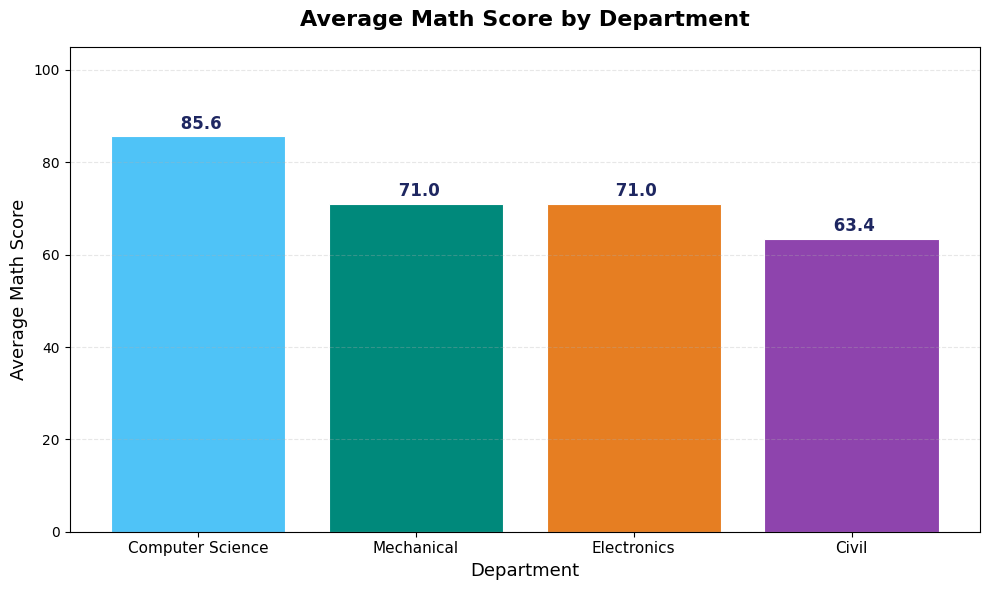

In [ ]:
# CELL 16: Chart 1 - Bar Chart: Average Math Score by Department

# Step 1: Get data using SQL
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
# pd.read_sql_query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_math'

# Step 2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
# fig = the whole figure (canvas)
# ax = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall
#figsize=(10,6)= 10 inches wide m 6 inches tall

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
# List of hex color codes - one color per department bar
# Same color palette as our PPT slides for consistency
bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# y position: just above bar top
# text: height formatted to 1 decimal
# horizontal/vertical alignment

# x-axis values (category labels)
# y-axis values (heights of bars)
# colors for each bar
# white border around each bar
# thickness of the border

# ax.bar() draws one bar per x-value, with height = y-value

# Add value labels ON TOP of each bar
for bar in bars:
    # Loop through each bar object
    height = bar.get_height()
    # .get_height() returns the bar's height (= the avg_math value)
    ax.text(
        bar.get_x() + bar.get_width() / 2, # x position: center of bar
        height + 0.8,
        f'{height : .1f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#1E2761'
    )

ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105) # y-axis from @ to 105 so labels above bars fit
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
# axis='y' adds horizontal gridlines only
# alpha=0.3 makes gridlines 70% transparent
# linestyle=" -- ' makes them dashed

plt.tight_layout() # Adjusts spacing to prevent label clipping
# Displays the chart

plt.show()

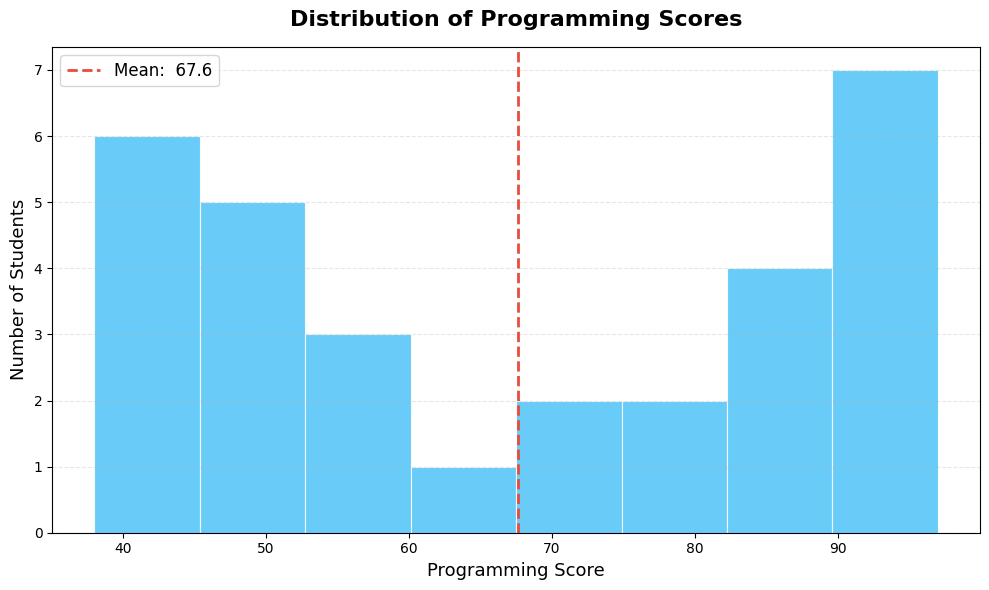

In [ ]:
# CELL 17: Chart 2 - Histogram: Distribution of Programming Scores

# Get programming scores as a list
prog_scores = df['programming_score'].tolist()
# .tolist() converts a Pandas Series to a regular Python list
# Matplotlib's hist() W -- 1
#(function) figsize: tuple[Literal[10], Literal[6]]
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(
# The data to visualize
# Divide score range into 8 equal intervals
# Bar fill color
# White border between bars

# Slight transparency

# ax.hist() returns three values:
#n= frequency count for each bin

prog_scores,
bins=8,
color='#4FC3F7',
edgecolor='white',
linewidth=0.8,
alpha=0.85
)

# bins

# x position of the vertical line
# red color for visibility
# dashed line style

# Add a vertical line showing the mean score
mean_score = sum(prog_scores) / len(prog_scores)

ax.axvline(
x=mean_score,
color='#E74C3C',
linestyle='--',
linewidth=2,
label=f'Mean: {mean_score: .1f}' # label for the legend
)
# axvline = 'axis vertical line' - draws a vertical reference line

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel( 'Number of Students', fontsize=13)
ax.legend(fontsize=12) # Shows the mean line label
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#Use this with any dataset (Kaggle or your own).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
'Category': np.random.choice(['A','B','C','D'], 100),
'Value': np.random.randint(10, 100, 100),
'Score': np.random.randint(1, 10, 100)
})

category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

fig = px.bar(
category_counts,
x='Category',
y='Count',
color='Category',
title='Interactive Category Distribution',
text='Count'
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category", yaxis_title="Count")

fig.show()